In [11]:
import torch
from diffusers import StableDiffusion3Pipeline
from huggingface_hub import login
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

DEVICE = "cuda"
DTYPE = torch.float16

pipe = StableDiffusion3Pipeline.from_pretrained(
    "stabilityai/stable-diffusion-3-medium-diffusers",
    torch_dtype=DTYPE,
).to(DEVICE)

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

In [12]:
# ── CONFIG — Experiment #7b: refined T5 × CLIP-G near working region ──
CONCEPT_PROMPT  = "a landscape in watercolor style"
NEUTRAL_PROMPTS = [
    "a landscape",
    "a photograph of a landscape",
    "a landscape in oil painting style",
    "a landscape, pencil sketch",
    "a landscape, digital art",
]
GEN_PROMPT      = "a landscape in watercolor style"

ALPHAS_C = [0]
ALPHAS_T = [100, 200, 300, 400]
ALPHAS_G = [0, 1, 2, 3]

NUM_STEPS       = 28
GUIDANCE_SCALE  = 7.0
SEED            = 42

In [13]:
def clear_all_hooks():
    pipe.transformer.time_text_embed._forward_hooks.clear()
    pipe.transformer.time_text_embed._forward_pre_hooks.clear()
    pipe.transformer.context_embedder._forward_hooks.clear()
    pipe.transformer.context_embedder._forward_pre_hooks.clear()
    for blk in pipe.transformer.transformer_blocks:
        blk._forward_hooks.clear()
        blk._forward_pre_hooks.clear()
clear_all_hooks()

def masked_mean(act, prompt, tokenizer, max_length):
    tok  = tokenizer(prompt, return_tensors="pt", padding="max_length",
                     max_length=max_length, truncation=True)
    mask = tok.attention_mask[0].bool()
    return act[mask].mean(dim=0)

def capture(prompt):
    ctx_steps = {}
    pooled_cache = {}
    counter = [0]
    def _ctx_hook(module, inp, out):
        ctx_steps[counter[0]] = out[1].detach().float()
        counter[0] += 1
    def _pooled_pre_hook(module, args):
        if "pooled" not in pooled_cache:
            pooled_cache["pooled"] = args[1][1].detach().float()
    h1 = pipe.transformer.context_embedder.register_forward_hook(_ctx_hook)
    h2 = pipe.transformer.time_text_embed.register_forward_pre_hook(_pooled_pre_hook)
    with torch.no_grad():
        pipe(prompt, num_inference_steps=NUM_STEPS, output_type="latent",
             generator=torch.Generator(DEVICE).manual_seed(0))
    h1.remove(); h2.remove()
    return ctx_steps, pooled_cache["pooled"]

# ── Capture concept once, capture each neutral, then average neutrals ──
print("Capturing concept activations...")
concept_ctx_steps, concept_pooled = capture(CONCEPT_PROMPT)

print(f"Capturing {len(NEUTRAL_PROMPTS)} neutral activations...")
all_neutral_ctx = []
all_neutral_pooled = []
for np_prompt in NEUTRAL_PROMPTS:
    print(f"  → {np_prompt}")
    nc, npool = capture(np_prompt)
    all_neutral_ctx.append(nc)
    all_neutral_pooled.append(npool)

# Average neutral activations across the anchor prompts (per-step)
neutral_ctx_steps = {}
for step in range(NUM_STEPS):
    stacked = torch.stack([nc[step] for nc in all_neutral_ctx])
    neutral_ctx_steps[step] = stacked.mean(dim=0)
neutral_pooled = torch.stack(all_neutral_pooled).mean(dim=0)

# ── Per-step CLIP-L and T5 directions ────────────────────────────────────
dir_clip_steps = {}
dir_t5_steps   = {}
for step in range(NUM_STEPS):
    diff = concept_ctx_steps[step] - neutral_ctx_steps[step]
    d = masked_mean(diff[:77], CONCEPT_PROMPT, pipe.tokenizer, 77)
    dir_clip_steps[step] = (d / (d.norm() + 1e-8)).to(DEVICE, dtype=DTYPE)
    if pipe.tokenizer_3 is not None:
        d = masked_mean(diff[77:], CONCEPT_PROMPT, pipe.tokenizer_3, 256)
        dir_t5_steps[step] = (d / (d.norm() + 1e-8)).to(DEVICE, dtype=DTYPE)

clipg_diff = concept_pooled[768:] - neutral_pooled[768:]
dir_clipg  = (clipg_diff / (clipg_diff.norm() + 1e-8)).to(DEVICE, dtype=DTYPE)

print(f"Per-step dirs: {len(dir_clip_steps)} CLIP-L, {len(dir_t5_steps)} T5")
print(f"CLIP-G pooled direction norm: {dir_clipg.norm().item():.4f}")

Capturing concept activations...


  0%|          | 0/28 [00:00<?, ?it/s]

Capturing 5 neutral activations...
  → a landscape


  0%|          | 0/28 [00:00<?, ?it/s]

  → a photograph of a landscape


...

  → a landscape, pencil sketch


  0%|          | 0/28 [00:00<?, ?it/s]

  → a landscape, digital art


  0%|          | 0/28 [00:00<?, ?it/s]

Per-step dirs: 28 CLIP-L, 28 T5
CLIP-G pooled direction norm: 1.0000


Running 16 combinations...


  0%|          | 0/28 [00:00<?, ?it/s]

c=0 t=100 g=0: ok (mean=112.0)


  0%|          | 0/28 [00:00<?, ?it/s]

c=0 t=100 g=1: ok (mean=111.3)


...

c=0 t=400 g=1: ok (mean=86.8)


  0%|          | 0/28 [00:00<?, ?it/s]

c=0 t=400 g=2: ok (mean=89.7)


  0%|          | 0/28 [00:00<?, ?it/s]

c=0 t=400 g=3: ok (mean=88.0)


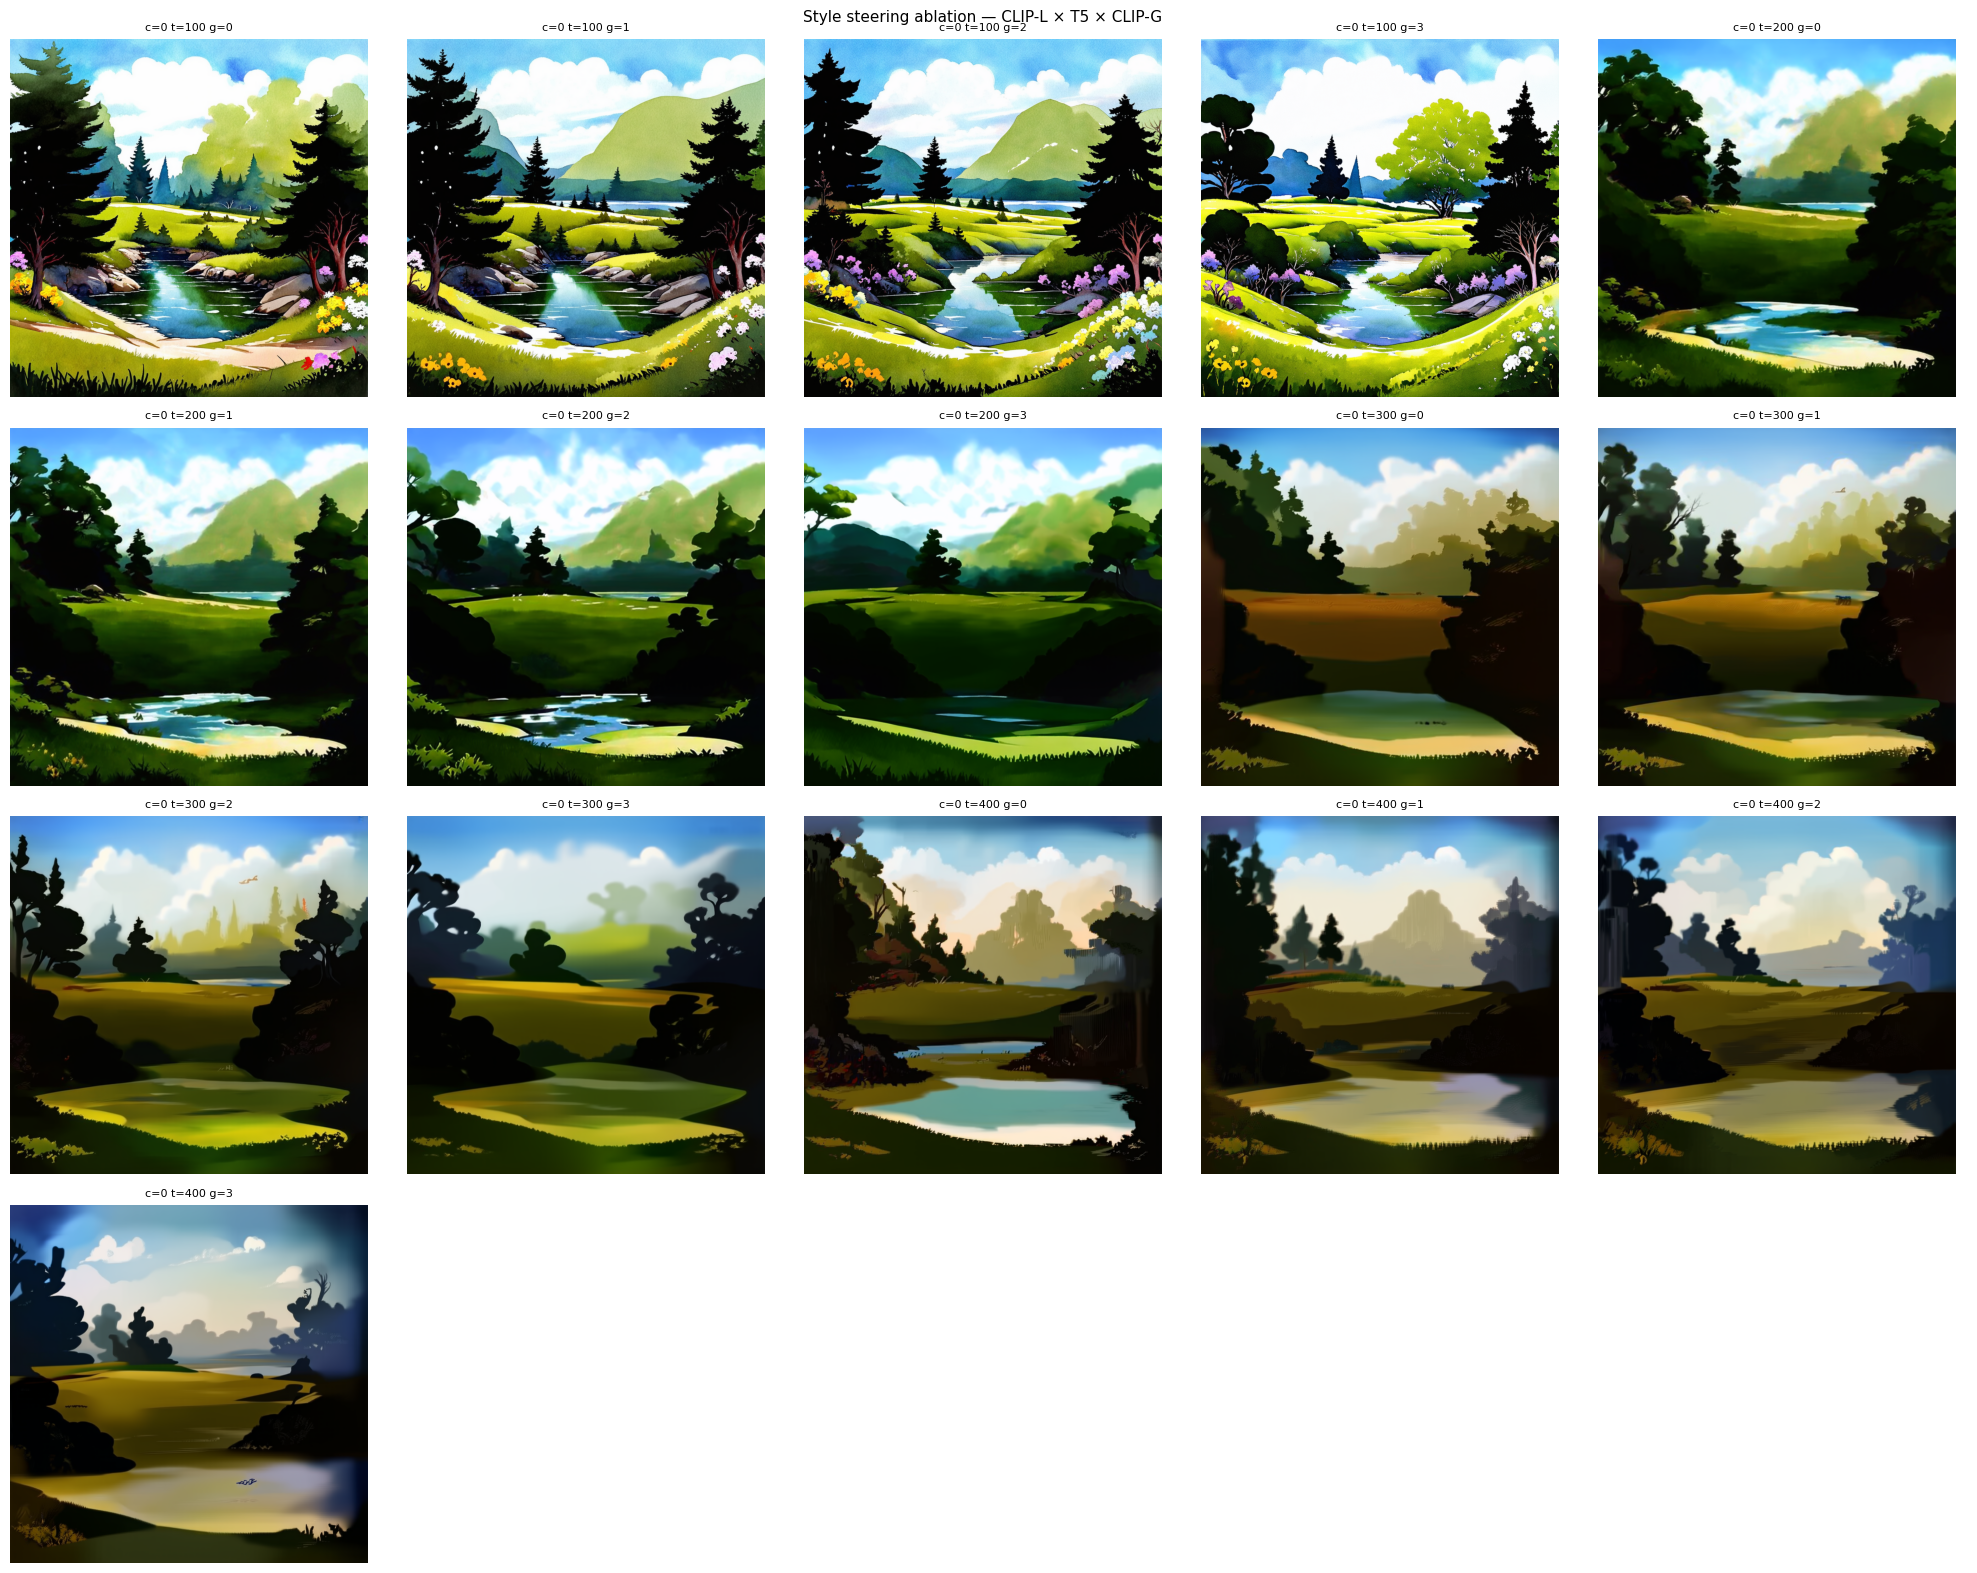

Saved → results/style_ablation_grid.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw
import itertools

def make_placeholder(label):
    img = Image.new('RGB', (512, 512), (40, 40, 40))
    ImageDraw.Draw(img).text((10, 240), label, fill=(255, 80, 80))
    return img

def run(a_clip, a_t5, a_clipg):
    counter = [0]
    def _ctx_hook(module, inp, out, _ac=a_clip, _at=a_t5):
        step = counter[0] % NUM_STEPS
        counter[0] += 1
        out_f = out.clone().float()
        d = dir_clip_steps[step].float()
        proj = torch.clamp(out_f[:, :77, :] @ d, min=0.0).unsqueeze(-1)
        out_f[:, :77, :] -= _ac * proj * d
        if step in dir_t5_steps:
            d = dir_t5_steps[step].float()
            proj = (out_f[:, 77:, :] @ d).unsqueeze(-1)  # no clip_negative — style is diffuse
            out_f[:, 77:, :] -= _at * proj * d
        return out_f.to(out.dtype)
    def _pooled_pre_hook(module, args, _ag=a_clipg):
        timestep, pooled = args
        pooled_f = pooled.clone().float()
        d = dir_clipg.float()
        proj = torch.clamp(pooled_f[:, 768:] @ d, min=0.0).unsqueeze(-1)
        pooled_f[:, 768:] -= _ag * proj * d
        return (timestep, pooled_f.to(pooled.dtype))
    h1 = pipe.transformer.context_embedder.register_forward_hook(_ctx_hook)
    h2 = pipe.transformer.time_text_embed.register_forward_pre_hook(_pooled_pre_hook)
    try:
        with torch.no_grad():
            img = pipe(GEN_PROMPT, guidance_scale=GUIDANCE_SCALE,
                       num_inference_steps=NUM_STEPS,
                       generator=torch.Generator(DEVICE).manual_seed(SEED)).images[0]
        arr = np.array(img)
        if arr.mean() > 250 or arr.mean() < 5:
            img = make_placeholder(f"c={a_clip} t={a_t5} g={a_clipg}")
            print(f"c={a_clip} t={a_t5} g={a_clipg}: degenerate")
        else:
            print(f"c={a_clip} t={a_t5} g={a_clipg}: ok (mean={arr.mean():.1f})")
    except Exception as e:
        img = make_placeholder(f"c={a_clip} t={a_t5} g={a_clipg}")
        print(f"error: {e}")
    finally:
        h1.remove(); h2.remove()
    return img

# Flat list of all combinations, displayed horizontally, max 5 per row
COLS = 5
all_params = list(itertools.product(ALPHAS_C, ALPHAS_T, ALPHAS_G))

print(f"Running {len(all_params)} combinations...")
results = []
for a_clip, a_t5, a_clipg in all_params:
    results.append((a_clip, a_t5, a_clipg, run(a_clip, a_t5, a_clipg)))

n = len(results)
n_cols = min(n, COLS)
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), squeeze=False)
for i, (a_clip, a_t5, a_clipg, img) in enumerate(results):
    r, c = divmod(i, n_cols)
    axes[r][c].imshow(img)
    axes[r][c].set_title(f"c={a_clip} t={a_t5} g={a_clipg}", fontsize=8)
    axes[r][c].axis("off")
for i in range(n, n_rows * n_cols):  # hide unused axes
    r, c = divmod(i, n_cols)
    axes[r][c].axis("off")
plt.suptitle("Style steering ablation — CLIP-L × T5 × CLIP-G", fontsize=11)
plt.tight_layout()
plt.show()
print("Saved → results/style_ablation_grid.png")

In [ ]:
# To generate baseline image
clear_all_hooks()

with torch.no_grad():
    baseline = pipe(
        NEUTRAL_PROMPT,
        guidance_scale=GUIDANCE_SCALE,
        num_inference_steps=NUM_STEPS,
        generator=torch.Generator(DEVICE).manual_seed(SEED),
    ).images[0]

clear_all_hooks()
display(baseline)
# baseline.save("baseline.png")